In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me
import random
#on va appliquer avce ce premier graphe le decentralized gradient descent 
# Sélection des points 
n, m, a = 100, 20, 5


sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 50000   # Nombre d'itérations

# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# solution pour le kernel ridge est un alpha * 
a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
b_star=Knm.T@y
alpha_star=np.linalg.solve(a_star,b_star)


#construction de la matrice W 
# Exemple : Graphe en cycle (chaque agent parle à ses 2 voisins)
W = np.zeros((a, a))
for i in range(a):
    W[i, i] = 0.5
    W[i, (i-1)%a] = 0.25
    W[i, (i+1)%a] = 0.25
    

#garaphe 2 - line 
W2=np.zeros((a, a))
for i in range(a):
            W2[i, i] = 0.6
            if i > 0: W2[i, i-1] = 0.2
            if i < a-1: W2[i, i+1] = 0.2
        # Ajustement des bords pour la double stochasticité
W2[0, 0], W2[-1, -1] = 0.8, 0.8


#graphe complet 
W3 = np.ones((a, a)) / a









C:\Users\BONETTI\AppData\Local\Temp\ipykernel_16800\1251615862.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


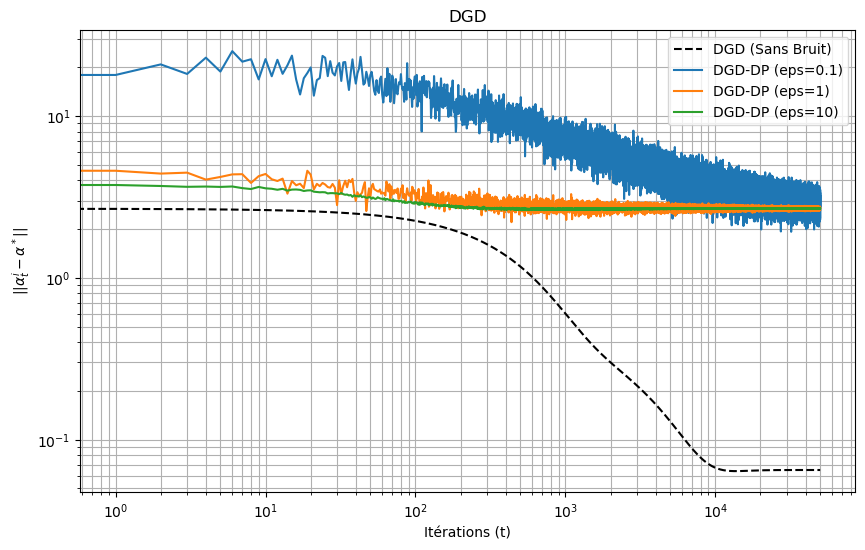

In [7]:
##### GT et DGD initialisation #######
alpha_dgd_simple = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_dgd_1 = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_dgd_2 = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_dgd_3 = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 


#pas 
eta_fixed=0.001

#epsilon 
epsi_1=0.1
epsi_2=1
epsi_3=10


############## erreur pour chaque modèle ##########

erreur_dgd_1=[]
erreur_dgd_2=[]
erreur_dgd_3=[]
erreur_dgd_simple=[]

###################################################

sensitivity = 0.5 
b_1 = sensitivity / epsi_1  # Scale pour eps=0.1 (Bruit fort)
b_2 = sensitivity / epsi_2  # Scale pour eps=1
b_3 = sensitivity / epsi_3  # Scale pour eps=10 (Bruit faible)

def gamma_k(t): return 1.0 / (1 + 0.1 * t**0.5) 
def alpha_k(t): return 0.05 / (1 + 0.01 * t)    
def nu_k(t, sens): return sens / (1+0.001*(t**0.1))













for t in range (n_iter):
    ######### DGD SIMPLE  ##########################
    #on fait les etapes pour DGD 
    new_alpha_simple= np.zeros_like(alpha_dgd_simple)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd_simple[i] + Ki.T @ (Ki @ alpha_dgd_simple[i] - yi) + (nu/a) * alpha_dgd_simple[i]
        new_alpha_simple[i] = W3[i, :] @ alpha_dgd_simple - eta_fixed * grad_i
    alpha_dgd_simple= new_alpha_simple
    erreur_dgd_simple.append(np.linalg.norm(alpha_dgd_simple - alpha_star, 'fro'))
    
    
    
    # --- DGD DP (Boucle sur les 3 epsilon) ---
    for eps_idx, (alpha_current, b_scale, erreur_list) in enumerate([
        (alpha_dgd_1, b_1, erreur_dgd_1), 
        (alpha_dgd_2, b_2, erreur_dgd_2), 
        (alpha_dgd_3, b_3, erreur_dgd_3)]):
        
        new_alpha = alpha_current.copy()
        
        # 1. Obfuscation : chaque agent génère son état bruité
        # Le bruit de Laplace est ajouté à chaque dimension (m) de alpha
        chi = alpha_current + np.random.laplace(0, b_scale, size=(a, m))
        
        for i in range(a):
            # 2. Calcul du gradient local
            idx_loc = range(i*20, (i+1)*20)
            Ki, yi = Knm[idx_loc, :], y[idx_loc]
            grad_i = (sigma**2/a)*Kmm @ alpha_current[i] + Ki.T @ (Ki @ alpha_current[i] - yi) + (nu/a)*alpha_current[i]
            
            # 3. Mise à jour DGD-DP
            # Somme des différences avec les voisins (W3[i,j] est le poids wij)
            diff_sum = np.zeros(m)
            for j in range(a):
                if i != j:
                    diff_sum += W3[i, j] * (chi[j] - alpha_current[i])
            
            # Formule : x_k+1 = x_k + gamma_k * diff - alpha_k * grad
            new_alpha[i] = alpha_current[i] + gamma_k(t) * diff_sum - alpha_k(t) * grad_i
            
        # Mise à jour de la variable et stockage erreur
        if eps_idx == 0: alpha_d_1 = new_alpha
        elif eps_idx == 1: alpha_d_2 = new_alpha
        else: alpha_d_3 = new_alpha
        
        erreur_list.append(np.linalg.norm(new_alpha - alpha_star, 'fro'))
    
    
    
    
    
    

    
    
        
   
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd_simple, 'k--', label='DGD (Sans Bruit)')
plt.loglog(erreur_dgd_1, label='DGD-DP (eps=0.1)')
plt.loglog(erreur_dgd_2, label='DGD-DP (eps=1)')
plt.loglog(erreur_dgd_3, label='DGD-DP (eps=10)')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('DGD')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


        
    
    
   
    


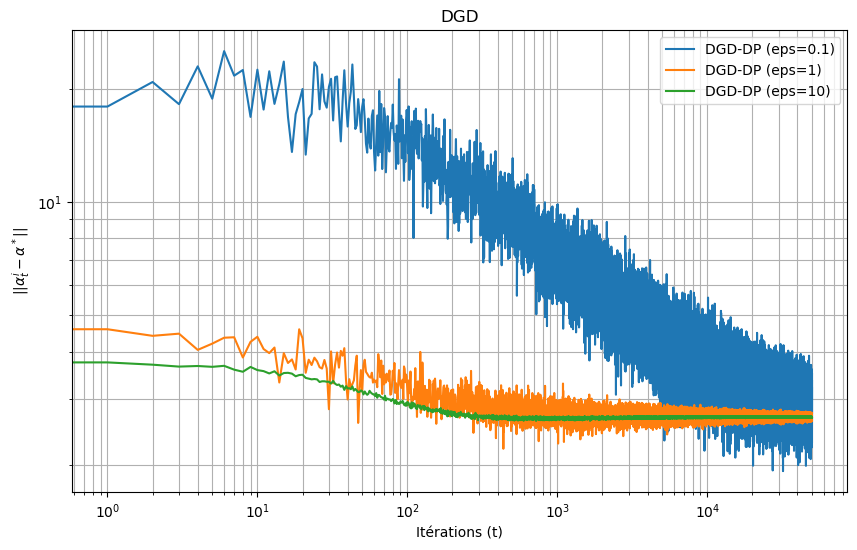

In [8]:
    
plt.figure(figsize=(10, 6))
#plt.loglog(erreur_dgd_simple, 'k--', label='DGD (Sans Bruit)')
plt.loglog(erreur_dgd_1, label='DGD-DP (eps=0.1)')
plt.loglog(erreur_dgd_2, label='DGD-DP (eps=1)')
plt.loglog(erreur_dgd_3, label='DGD-DP (eps=10)')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('DGD')
plt.legend()
plt.grid(True, which="both", ls="-")   
        
